In [48]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pisi3data/dados.csv
/kaggle/input/pisi3data/books.csv


In [49]:
df = pd.read_csv('/kaggle/input/pisi3data/dados.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11975 entries, 0 to 11974
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   titulo      11975 non-null  object 
 1   autor       11971 non-null  object 
 2   ISBN_13     11216 non-null  float64
 3   ISBN_10     11216 non-null  object 
 4   ano         11975 non-null  int64  
 5   paginas     11975 non-null  int64  
 6   idioma      11973 non-null  object 
 7   editora     11974 non-null  object 
 8   rating      11975 non-null  float64
 9   avaliacao   11975 non-null  int64  
 10  resenha     11975 non-null  int64  
 11  abandonos   11975 non-null  int64  
 12  relendo     11975 non-null  int64  
 13  querem_ler  11975 non-null  int64  
 14  lendo       11975 non-null  int64  
 15  leram       11975 non-null  int64  
 16  descricao   11318 non-null  object 
 17  genero      11386 non-null  object 
 18  male        11975 non-null  int64  
 19  female      11975 non-nul

In [50]:
df.isnull().sum()

titulo          0
autor           4
ISBN_13       759
ISBN_10       759
ano             0
paginas         0
idioma          2
editora         1
rating          0
avaliacao       0
resenha         0
abandonos       0
relendo         0
querem_ler      0
lendo           0
leram           0
descricao     657
genero        589
male            0
female          0
dtype: int64

In [51]:
df['ISBN_13'] = df['ISBN_13'].fillna('Desconhecido')
df['ISBN_10'] = df['ISBN_10'].fillna('Desconhecido')
df['descricao'] = df['descricao'].fillna('Desconhecido')
df['genero'] = df['genero'].fillna('Desconhecido')
df['autor'] = df['autor'].fillna('Desconhecido')
df['editora'] = df['editora'].fillna('Desconhecido')
df['idioma'] = df['idioma'].fillna('Desconhecido')

df['abandonos'] = df['abandonos'].astype(int)
df['querem_ler'] = df['querem_ler'].astype(int)
df['lendo'] = df['lendo'].astype(int)
df['relendo'] = df['relendo'].astype(int)
df['leram'] = df['leram'].astype(int)

In [52]:
df.isnull().sum()

titulo        0
autor         0
ISBN_13       0
ISBN_10       0
ano           0
paginas       0
idioma        0
editora       0
rating        0
avaliacao     0
resenha       0
abandonos     0
relendo       0
querem_ler    0
lendo         0
leram         0
descricao     0
genero        0
male          0
female        0
dtype: int64

informações utéis para EDA

autor

idioma

abandonos
querem_ler
lendo
leram
relendo

genero

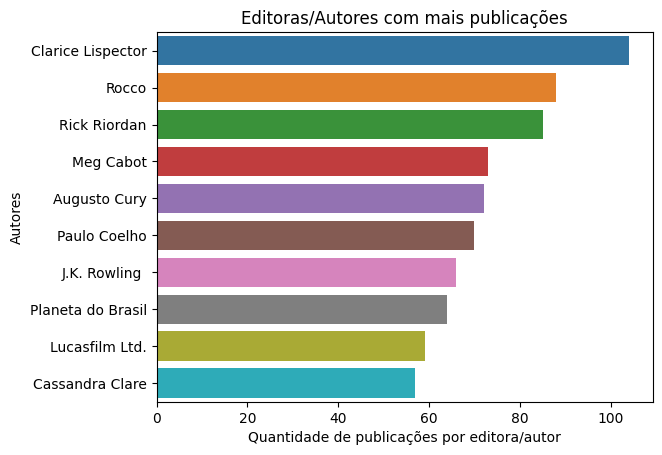

In [53]:
#Dataframe da EDA, sujeito a modificacoes
EDAdf =  df.copy()

#Incidencia de autores
EDAdf['nAutores'] = 1

nAutores = EDAdf.groupby('autor')['nAutores'].sum()
nAutores = nAutores.sort_values(ascending = False)

plt.title('Editoras/Autores com mais publicações')
sns.barplot(x = nAutores.head(10).values, y=nAutores.head(10).index)
plt.ylabel('Autores')
plt.xlabel('Quantidade de publicações por editora/autor')
plt.savefig("aparicoesAutores.png", bbox_inches="tight")

In [54]:
EDAdf['nIdiomas'] = EDAdf['nAutores']
EDAdf = EDAdf.drop('nAutores', axis=1)

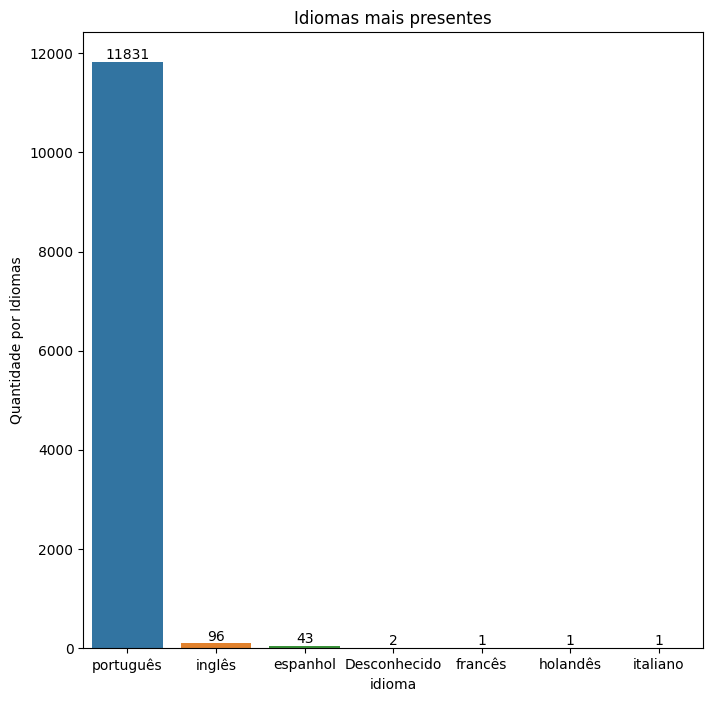

In [55]:
nIdiomas = EDAdf.groupby('idioma')['nIdiomas'].sum()
nIdiomas = nIdiomas.sort_values(ascending = False)

plt.figure(figsize=(8, 8))
plt.title('Idiomas mais presentes')

ax = sns.barplot(x = nIdiomas.head(10).index, y= nIdiomas.head(10).values)

for container in ax.containers:
    ax.bar_label(container)

plt.ylabel('Quantidade por Idiomas')
plt.savefig("nIdiomas.png", bbox_inches="tight")
EDAdf = EDAdf.drop('nIdiomas', axis=1)

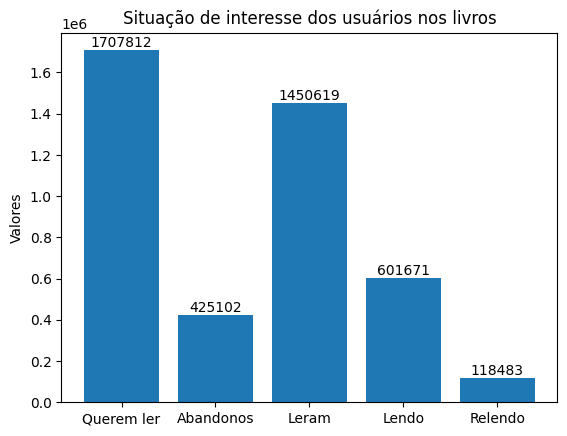

In [56]:
querem_ler = df['querem_ler'].sum()
abandonos = df['abandonos'].sum()
leram = df['leram'].sum()
lendo = df['lendo'].sum()
relendo = df['relendo'].sum()

valores = [querem_ler, abandonos, leram, lendo, relendo]
nomes = ['Querem ler', 'Abandonos', 'Leram', 'Lendo', 'Relendo']

plt.bar(nomes, valores)
plt.title('Situação de interesse dos usuários nos livros')
plt.ylabel('Valores')
for i, valor in enumerate(valores):
    plt.text(i, valor, str(valor), ha='center', va='bottom')
plt.savefig("status.png", bbox_inches="tight")

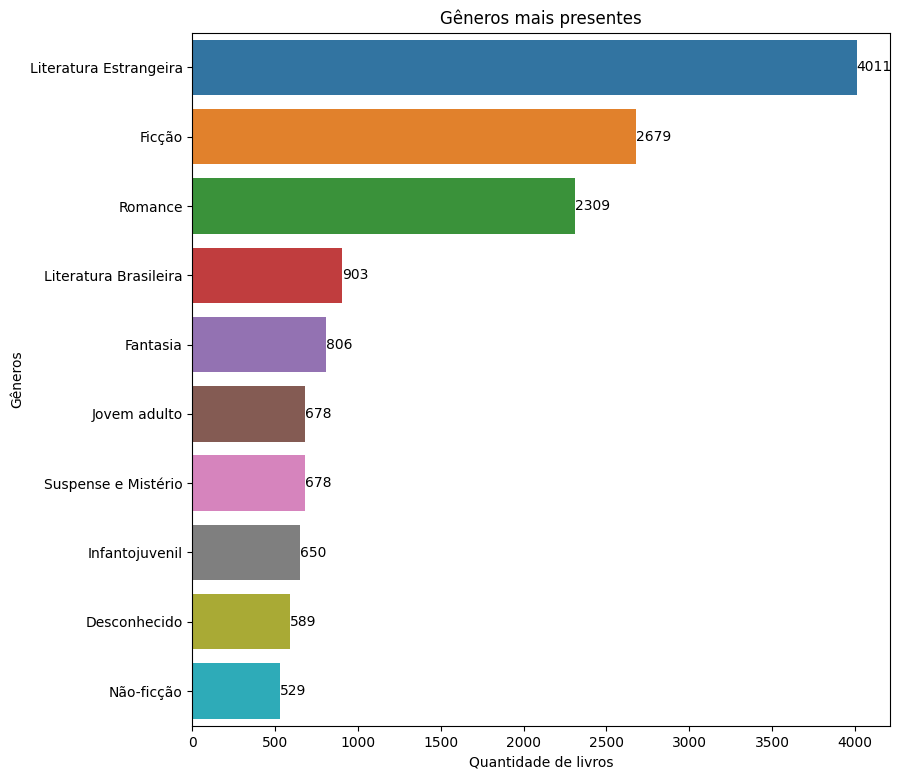

In [57]:
def explode_generos(df, coluna_genero, col_valor):
    df_copy = df.copy()
 
    df_copy[coluna_genero] = df_copy[coluna_genero].str.split(' / ')
   
    df_exploded = df_copy.explode(coluna_genero)
    
    df_exploded[coluna_genero] = df_exploded[coluna_genero].str.strip()

    df_agrupado = df_exploded.groupby(coluna_genero)[col_valor].sum().sort_values(ascending=False)
    return df_agrupado


dfGeneros = pd.DataFrame()
dfGeneros['genero'] = EDAdf['genero'].copy()
dfGeneros['contagem'] = 1
dfGeneros = explode_generos(dfGeneros, 'genero', 'contagem').head(20)
dfGeneros = dfGeneros.drop('')

plt.figure(figsize=(9, 9))
plt.title('Gêneros mais presentes')

nGeneros = sns.barplot(x = dfGeneros.head(10).values, y= dfGeneros.head(10).index)

for container in nGeneros.containers:
    nGeneros.bar_label(container)

plt.xlabel("Quantidade de livros")
plt.ylabel('Gêneros')
plt.savefig("nGeneros.png", bbox_inches="tight")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


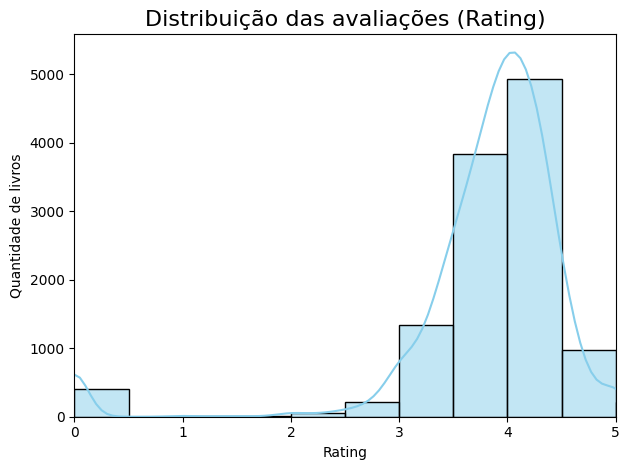

In [58]:
sns.histplot(EDAdf['rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribuição das avaliações (Rating)', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Quantidade de livros')
plt.xlim(0,5)
plt.tight_layout()
plt.savefig("distribuicao_rating.png", bbox_inches="tight")
plt.show()

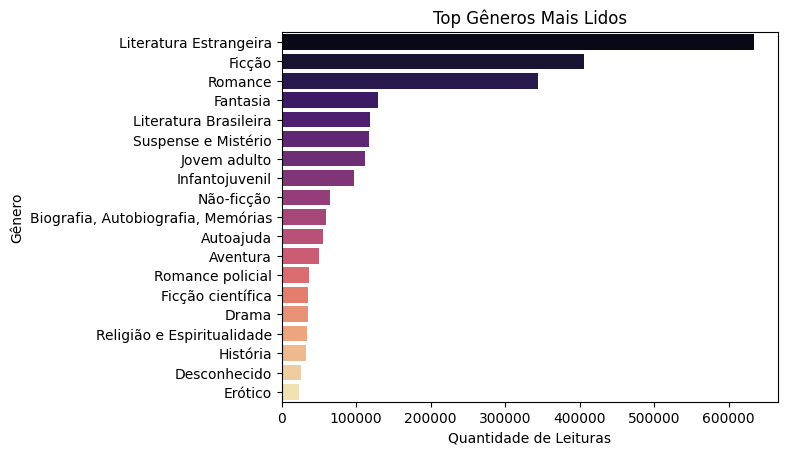

In [59]:
generos_mais_lidos = explode_generos(df, 'genero', 'leram').head(20)
generos_mais_lidos.drop(index='', inplace=True)
plt.figure()
sns.barplot(x=generos_mais_lidos.values, y=generos_mais_lidos.index, palette="magma")
plt.title("Top Gêneros Mais Lidos")
plt.xlabel("Quantidade de Leituras")
plt.ylabel("Gênero")
plt.savefig("generosMaisLidos.png", bbox_inches="tight")
plt.show()

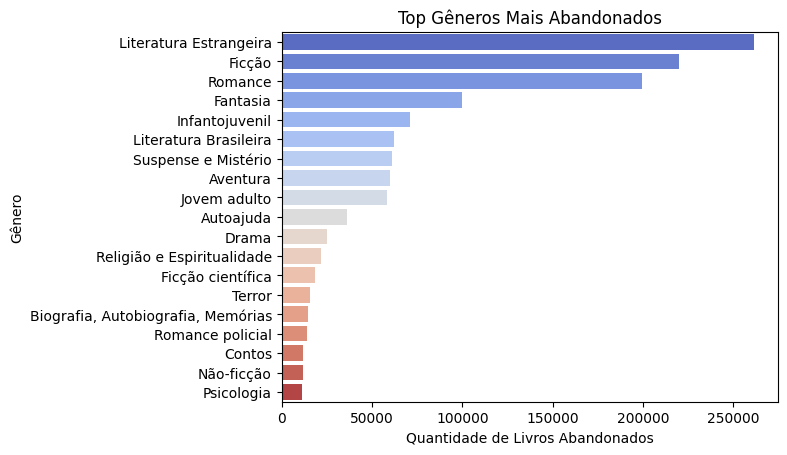

In [60]:
generos_mais_abandonados = explode_generos(df, 'genero', 'abandonos').head(20)
generos_mais_abandonados.drop(index='', inplace=True)
plt.figure()
sns.barplot(x=generos_mais_abandonados.values, y=generos_mais_abandonados.index, palette="coolwarm")
plt.title("Top Gêneros Mais Abandonados")
plt.xlabel("Quantidade de Livros Abandonados")
plt.ylabel("Gênero")
plt.savefig("generosMaisAbandonados.png", bbox_inches="tight")
plt.show()